## Leçon 6:  Différences finies avec numpy.

#### Petit exemple de solution de l'équation de conduction de la chaleur transitoire en 3 dimensions. 

#### La programmation est très élémentaire, on ne fait pas utilisation de fonctions ou de vectorisation. Tout est fait de façon primaire. Le code n'est donc pas très compact, par contre il est facilement lisible et n'utilise pas de 'trucs' numpy. On verra plus tard des outils pour mieux profiter de numpy.

L'équation est donc 
$$ \rho C_p  \frac {\partial T}{\partial t } = k \left (\frac {\partial ^{2} T}{\partial x^{2} } +\frac {\partial ^{2} T}{\partial y^{2} }  + \frac {\partial ^{2} T}{\partial z^{2} } \right)$$

Les conditions initiales et aux limites du problème sont intéressantes car on cherche à modéliser le traitement par laser de la peau.
On a donc un laser à impulsion qui décharge 30000 joules en 0.05 seconde sur une cible de 1 mm carré. La peau est exposée à l'air ambiant avec un coefficient h de 30 w/m2-degré C, la température ambiante est de 20 degrés. La radiation de la peau est considérée, on utilisera une émissivité de 1 et on approximera la radiation en utilisant la forme linéarisée (coefficient h radiatif). Sur les autres limites on a des conditions de Newman, c-a-d gradient nul. 

Le volume de peau modélisé est un cube de 6 mm de côté.

Le problème est presque identique à un devoir de GCH205 2015, réalisé avec Matlab.

À la fin du calcul on trace les profils sur la peau et à quelques profondeurs.

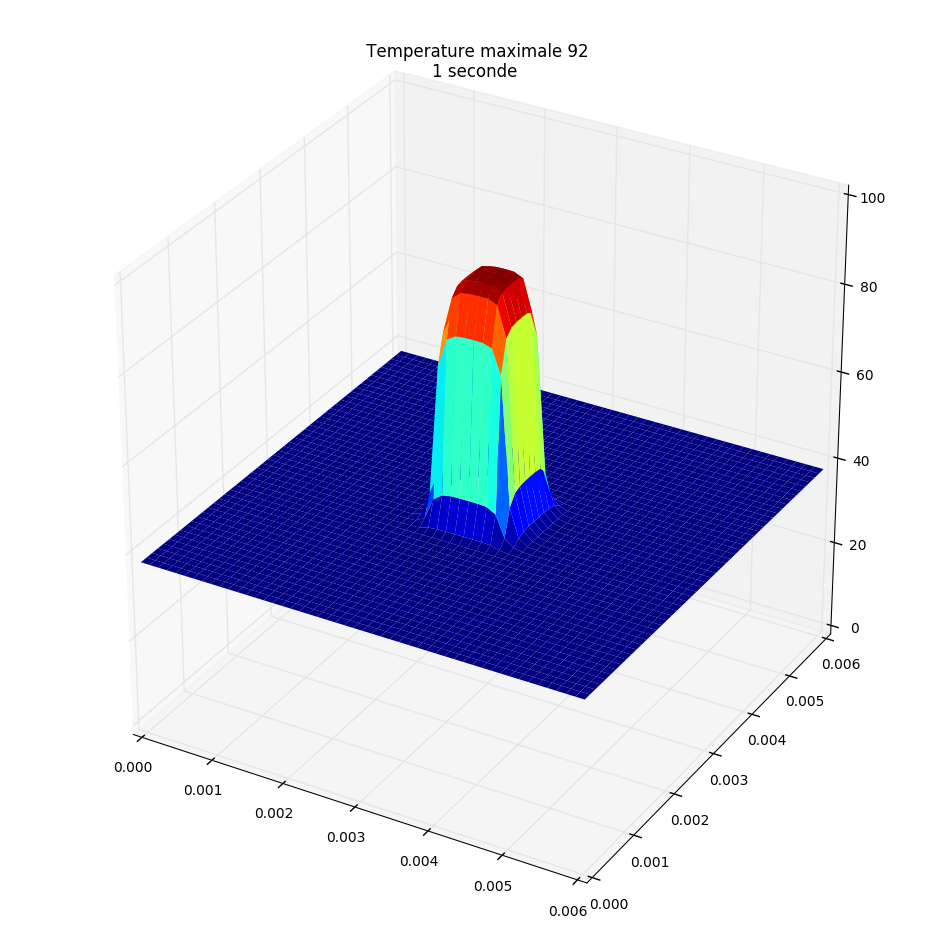

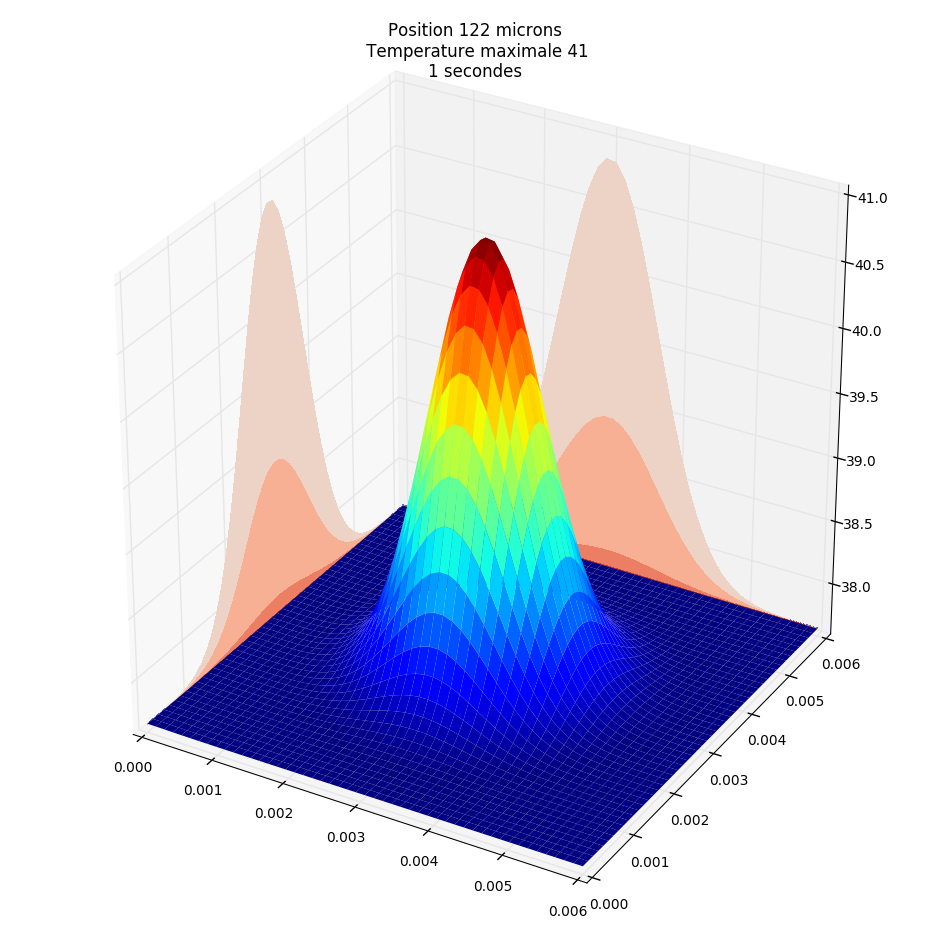

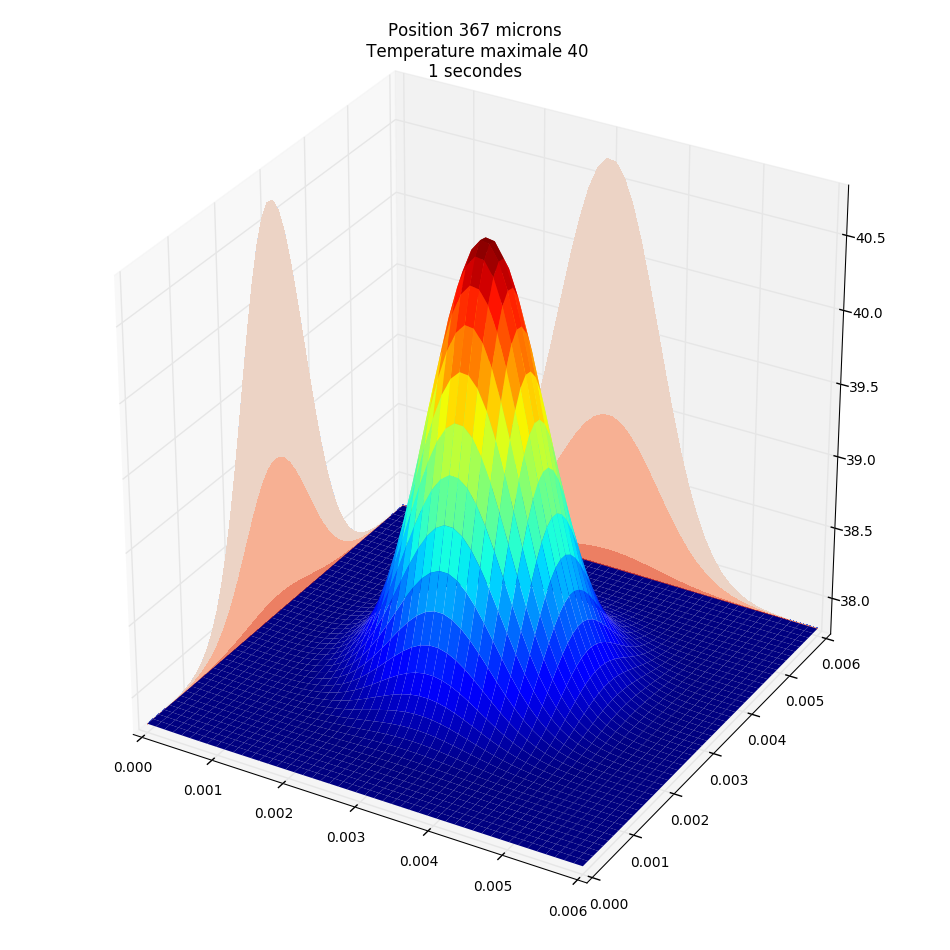

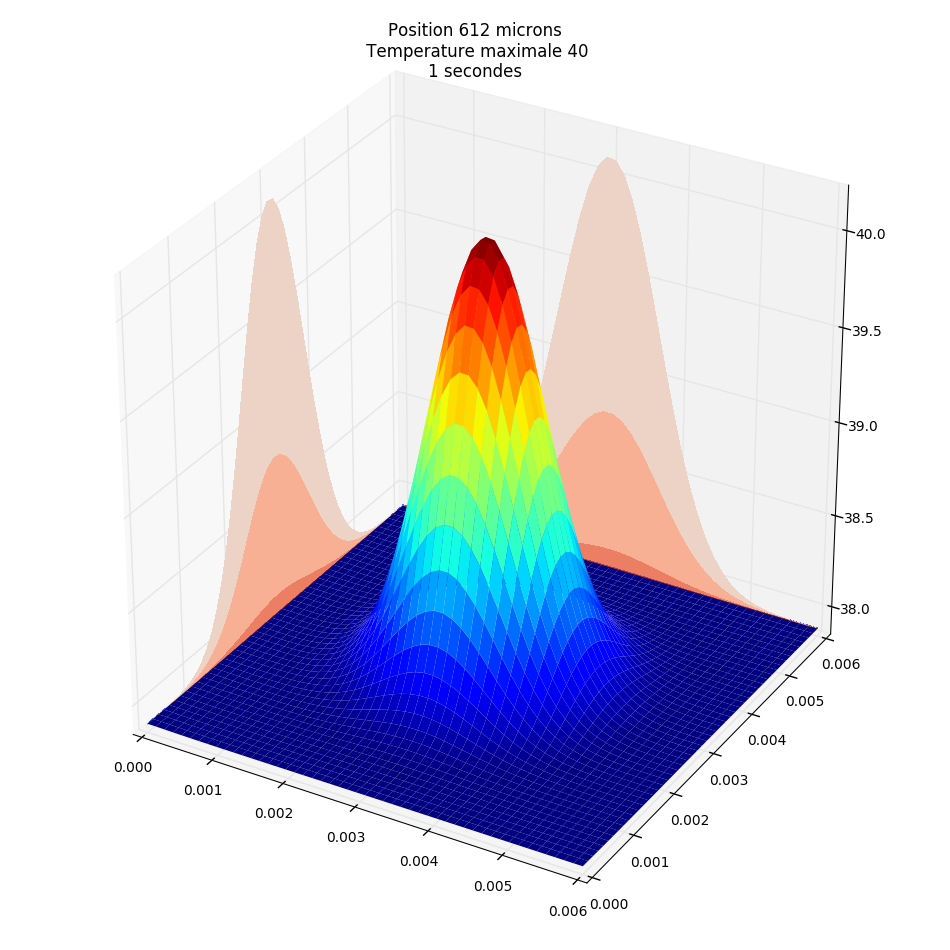

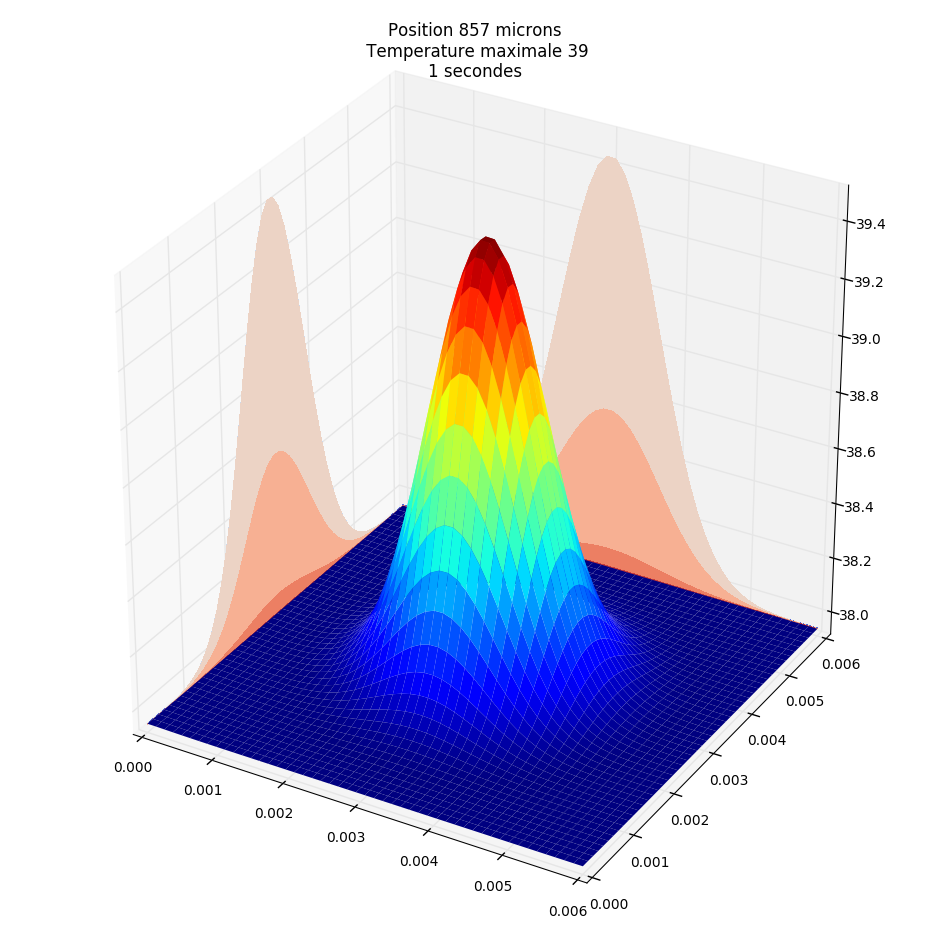

In [49]:
from IPython.display import *
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline
sp.init_printing(use_latex=True)
#
# Initialisations
#
E=3e4
carre=0.001
surface=carre*carre
tlaser=0.05
flux=E/tlaser
epsilon=1
nx=50
ny=50
nz=50
X=0.006                            # largeur 
Y=0.006                            # épaisseur
Z=0.006                            # profondeur
dx=X/(nx-1)
dy=Y/(ny-1)
dz=Z/(nz-1)                        # temps de la simulation
k=.66
cp=4180
rho=977                           # donnees thermo-physiques
alpha=k/rho/cp
#
#
dt=dx**2/(12*alpha)                 # determine dt ( la moitie du dt limite )
temps=1
h=30                                # coefficient h
sigma=5.67e-8                       # St6efan-Boltzmann
Tinf=20                             # temperature de l'air
Tinit=38                            # Température initiale 
T=np.ones(((nx,ny,nz))) *Tinit      # Mettre cette temperature sur chaque point 
x=np.linspace(0,X,nx)
y=np.linspace(0,Y,ny)
z=np.linspace(0,Z,nz)
#
#                  Position du petit carré cible au milieu
#                  du domaine
inX=[False]*nx
inY=[False]*ny
for i in range(len(inX)):
    if x[i] > X/2-carre/2  and x[i]  < X/2+carre/2:
        inX[i]=True
for i in range(len(inY)):
    if y[i] > Y/2-carre/2  and y[i]  < Y/2+carre/2:
        inY[i]=True       
#
a=alpha*dt/dx**2;      # coefficients de l'equation aux différences
b=alpha*dt/dy**2;
c=alpha*dt/dz**2;
d=1-2*a-2*b-2*c    # on s'est assure en calculant dt que d sera egal a 0.5
#
#
# Section faisant le calcul sur tous les points interieurs
#
compteur = 0
t=0;
XX,YY=np.meshgrid(x,y)
while t<temps:                                       # boucle sur t 
    compteur=compteur+1
    t=t+dt
    for ii in range(1,nx-1):                         # boucle sur x
        for jj in range( 1,ny-1):                    # boucle sur y  
            for kk in range(1,nz-1):                 # boucle sur z
                temp=     a*T[ii+1,jj,kk]
                temp=temp+a*T[ii-1,jj,kk]
                temp=temp+b*T[ii,jj+1,kk]
                temp=temp+b*T[ii,jj-1,kk]
                temp=temp+c*T[ii,jj,kk+1]
                temp=temp+c*T[ii,jj,kk-1]
                temp=temp+d*T[ii,jj,kk]
                T[ii,jj,kk]=temp             
#    
# Section conditions aux limites  
#
    T[-1,:,:]=T[-2,:,:]
    T[:,-1,:]=T[:,-2,:]
    T[:,:,-1]=T[:,:,-2]               # Newman presque partout
    T[0,:,:]=T[1,:,:]
    if t < tlaser:
        for i in range(0,nx):
            for j in range(0,ny):
                if inX[i] and inY[j]:                
                    T[i,j,0]=T[i,j,1]+flux/k*dz # pendant le laser
                else:
                    Tavg=(T[i,j,0]+Tinf)/2 +273
                    hrad=sigma*epsilon*Tavg**3  # après le laser
                    T[i,j,0]=((h+hrad)*Tinf+k/dz*T[i,j,1])/(h+k/dz)
    else:
        for i in range(0,nx):
            for j in range(0,ny):
                Tavg=(T[i,j,0]+Tinf)/2 +273
#                hrad=sigma*epsilon*Tavg**3  
                T[i,j,0]=((h+hrad)*Tinf+k/dz*T[i,j,1])/(h+k/dz)        
    T[:,0,:]=T[:,1,:]
#
# Tracer les résultats
#
    if t > tlaser and t-dt < tlaser:
        fig=plt.figure(i,figsize=(12,12))  
        ZZ=T[:,:,0]
        ax = fig.gca(projection='3d')
        ax.set_zlim3d(0,100)
        surf = ax.plot_surface(XX, YY, ZZ, rstride=1, cstride=1, cmap=cm.jet,
                       linewidth=0, antialiased=True)
        tmax=int(np.max(ZZ))
        titre=' Temperature maximale '+str(tmax)+'\n'
        titre=titre+str(temps)+" seconde"
        plt.title(titre)
        plt.show()
for i in range(1,9,2):
    fig=plt.figure(i,figsize=(12,12))  
    ZZ=T[:,:,i]
    ax = fig.gca(projection='3d')
    ax.set_zlim3d(T[0,0,i],np.max(ZZ))
    surf = ax.plot_surface(XX, YY, ZZ, rstride=1, cstride=1, cmap=cm.jet,
       linewidth=0, antialiased=True)
    cset = ax.contourf(XX, YY, ZZ, zdir='x', offset=0, cmap=cm.coolwarm)
    cset = ax.contourf(XX, YY, ZZ, zdir='y', offset=Y, cmap=cm.coolwarm)
    pos=z[i]*1000000
    titre='Position '+str(int(pos))+' microns\n'
    tmax=int(np.max(ZZ))
    titre=titre+' Temperature maximale '+str(tmax)+'\n'
    titre=titre+str(temps)+' secondes'
    plt.title(titre)
    plt.show()  